In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../src')
print('Notebook ready!')

Notebook ready!


## Step 1 — Load and clean data

In [2]:
from data_loader import load_data, create_target, handle_missing

df = load_data('../data/ADHD.xlsx')
df = create_target(df)
df = handle_missing(df)

Data loaded successfully — 506 rows, 110 columns
Target created — ADHD Positive: 251, Negative: 255
Missing values handled successfully


## Step 2 — Build full feature matrix (124 features) and check class balance

In [3]:
from feature_engineering import build_feature_matrix, check_class_imbalance
from model import split_data

# Build full feature matrix BEFORE selection
X, vectorizer = build_feature_matrix(df)
y = df['target'].values

# Split first — ALWAYS split before feature selection to prevent data leakage
X_train, X_test, y_train, y_test = split_data(X, y)

# Keep full (un-selected) versions for before/after comparison
X_train_full = X_train
X_test_full  = X_test

# Check class imbalance
is_imbalanced = check_class_imbalance(y_train)

Numeric features selected: 20
Categorical features encoded: 4
TF-IDF features created: 100 words/phrases

Full feature matrix: 506 rows x 124 features
Training set : 404 rows
Testing set  : 102 rows

  CLASS IMBALANCE CHECK
  ADHD Negative (0) : 204 (50.5%)
  ADHD Positive (1) : 200 (49.5%)
  Imbalance ratio   : 1.020
  Status: BALANCED — no handling needed


## Step 3 — Apply feature selection (Mutual Info, k=20)

In [6]:
from feature_engineering import apply_feature_selection

X_train_sel, X_test_sel, selector = apply_feature_selection(
    X_train, y_train, X_test, k=20
)


Applying feature selection...
  Features before selection : 124


C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings

  Features after selection  : 20
  Features removed          : 104


C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
C:\Users\Laptop\adhd_project\venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:69: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings

## Step 4 — Train all 5 models on selected features

In [7]:
from model import (
    train_logistic_regression, train_svm,
    train_xgboost, train_mlp, train_stacking,
    save_model
)

lr_model    = train_logistic_regression(X_train_sel, y_train)
svm_model   = train_svm(X_train_sel, y_train)
xgb_model   = train_xgboost(X_train_sel, y_train)
mlp_model   = train_mlp(X_train_sel, y_train)
stack_model = train_stacking(X_train_sel, y_train)

save_model(lr_model,    'logistic_regression.pkl')
save_model(svm_model,   'svm.pkl')
save_model(xgb_model,   'xgboost.pkl')
save_model(mlp_model,   'mlp.pkl')
save_model(stack_model, 'stacking.pkl')

print('\nAll models trained and saved!')


Training Logistic Regression...
Done!

Training SVM (linear kernel)...
Done!

Training XGBoost...
Done!

Training MLP (Neural Network)...
Done!

Training Stacking Ensemble (LR + XGBoost)...
Done!
Saved: ../models\logistic_regression.pkl
Saved: ../models\svm.pkl
Saved: ../models\xgboost.pkl
Saved: ../models\mlp.pkl
Saved: ../models\stacking.pkl

All models trained and saved!


## Step 5 — Evaluate each model individually


  Results for: Logistic Regression
  Accuracy  : 81.4%
  F1 Score  : 80.8%
  Precision : 83.3%
  Recall    : 78.4%
               precision    recall  f1-score   support

ADHD Negative       0.80      0.84      0.82        51
ADHD Positive       0.83      0.78      0.81        51

     accuracy                           0.81       102
    macro avg       0.81      0.81      0.81       102
 weighted avg       0.81      0.81      0.81       102



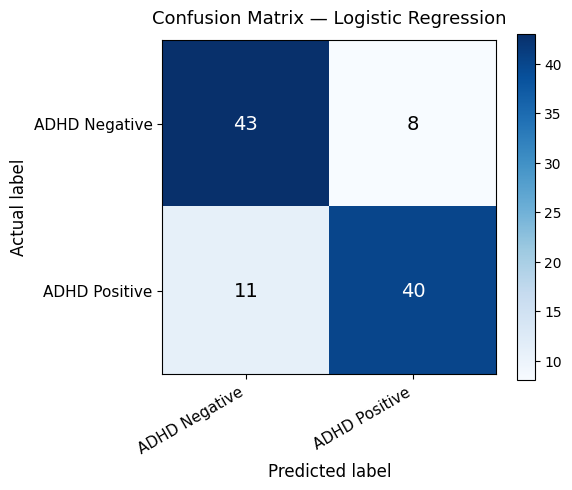

Saved: ../models/Logistic_Regression_cm.png

  Results for: SVM (Linear)
  Accuracy  : 81.4%
  F1 Score  : 80.4%
  Precision : 84.8%
  Recall    : 76.5%
               precision    recall  f1-score   support

ADHD Negative       0.79      0.86      0.82        51
ADHD Positive       0.85      0.76      0.80        51

     accuracy                           0.81       102
    macro avg       0.82      0.81      0.81       102
 weighted avg       0.82      0.81      0.81       102



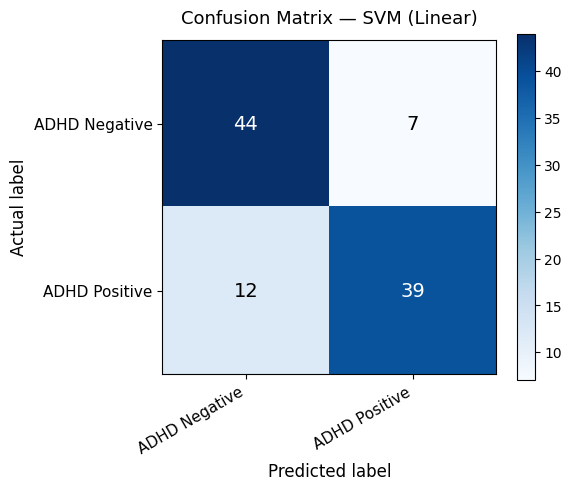

Saved: ../models/SVM_(Linear)_cm.png

  Results for: XGBoost
  Accuracy  : 75.5%
  F1 Score  : 75.2%
  Precision : 76.0%
  Recall    : 74.5%
               precision    recall  f1-score   support

ADHD Negative       0.75      0.76      0.76        51
ADHD Positive       0.76      0.75      0.75        51

     accuracy                           0.75       102
    macro avg       0.76      0.75      0.75       102
 weighted avg       0.75      0.75      0.75       102



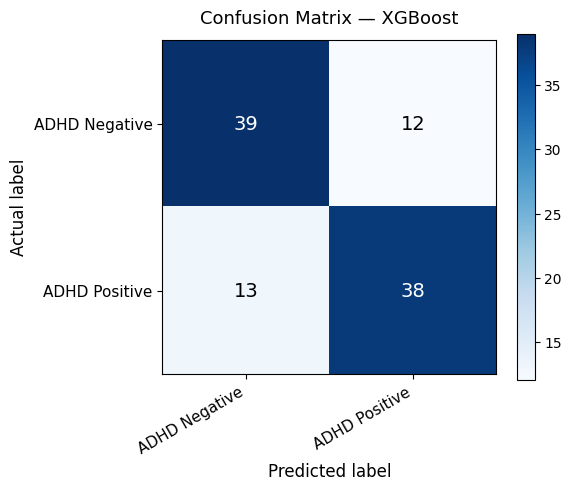

Saved: ../models/XGBoost_cm.png

  Results for: MLP
  Accuracy  : 69.6%
  F1 Score  : 69.3%
  Precision : 70.0%
  Recall    : 68.6%
               precision    recall  f1-score   support

ADHD Negative       0.69      0.71      0.70        51
ADHD Positive       0.70      0.69      0.69        51

     accuracy                           0.70       102
    macro avg       0.70      0.70      0.70       102
 weighted avg       0.70      0.70      0.70       102



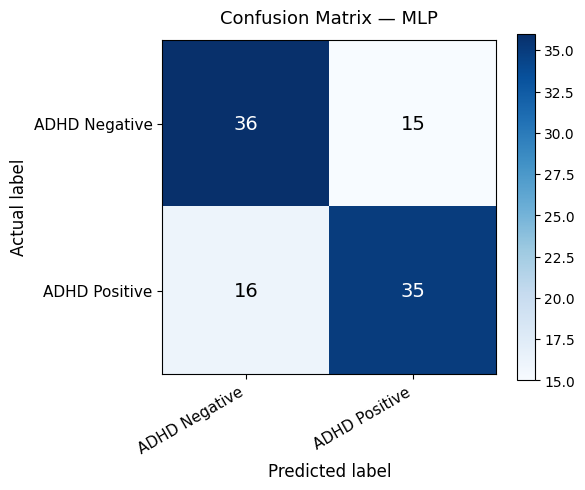

Saved: ../models/MLP_cm.png

  Results for: Stacking (LR+XGB)
  Accuracy  : 81.4%
  F1 Score  : 80.0%
  Precision : 86.4%
  Recall    : 74.5%
               precision    recall  f1-score   support

ADHD Negative       0.78      0.88      0.83        51
ADHD Positive       0.86      0.75      0.80        51

     accuracy                           0.81       102
    macro avg       0.82      0.81      0.81       102
 weighted avg       0.82      0.81      0.81       102



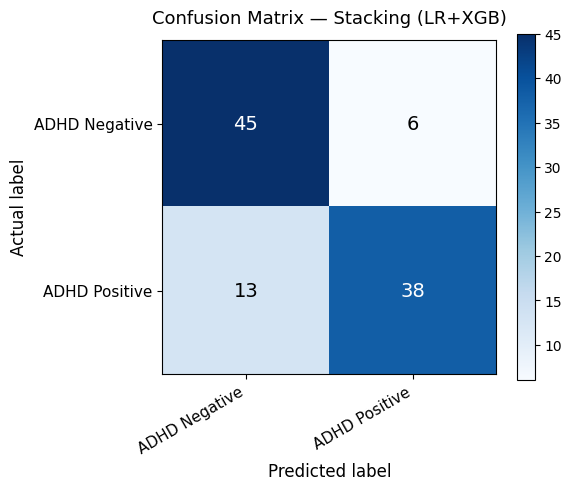

Saved: ../models/Stacking_(LR+XGB)_cm.png


In [8]:
from evaluate import evaluate_model, plot_confusion_matrix

all_models = {
    'Logistic Regression' : lr_model,
    'SVM (Linear)'        : svm_model,
    'XGBoost'             : xgb_model,
    'MLP'                 : mlp_model,
    'Stacking (LR+XGB)'   : stack_model,
}

preds = {}
for name, model in all_models.items():
    preds[name] = evaluate_model(model, X_test_sel, y_test, name)
    plot_confusion_matrix(y_test, preds[name], name)

## Step 6 — Before vs After Feature Selection Comparison

This cell retrains each model on the **full 124 features** and the **selected 20 features**  
to show exactly how much feature selection improved performance.


  BEFORE vs AFTER FEATURE SELECTION  (Before = 124 features,  After = 20 features)
  Model                          Accuracy       F1   Recall   Precision
  ----------------------------------------------------------------------------------------
  Logistic Regression     Before      79.4%    78.8%    76.5%       81.2%
                           After      81.4%    80.8%    78.4%       83.3%
                          Change      +2.0%    +2.0%    +2.0%       +2.1%
  ----------------------------------------------------------------------------------------
  SVM (Linear)            Before      73.5%    72.7%    70.6%       75.0%
                           After      81.4%    80.4%    76.5%       84.8%
                          Change      +7.8%    +7.7%    +5.9%       +9.8%
  ----------------------------------------------------------------------------------------
  XGBoost                 Before      76.5%    76.0%    74.5%       77.6%
                           After      79.4%    79.6% 

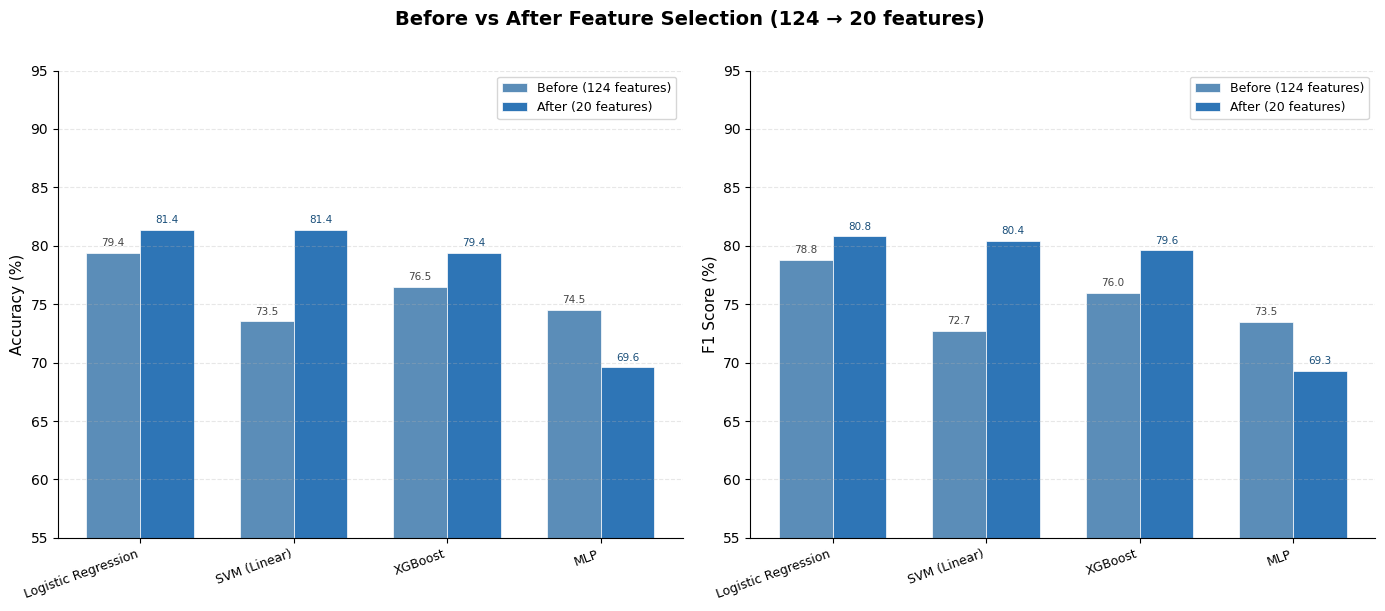

Saved: ../models/before_after_feature_selection.png


In [9]:
from evaluate import compare_before_after_selection
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

# Pass UNFITTED model copies — the function trains them internally
unfitted_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM (Linear)'        : SVC(kernel='linear', probability=True, random_state=42),
    'XGBoost'             : GradientBoostingClassifier(
                                learning_rate=0.05, n_estimators=200,
                                max_depth=4, random_state=42),
    'MLP'                 : MLPClassifier(
                                hidden_layer_sizes=(128,64,32), alpha=0.001,
                                max_iter=500, random_state=42, early_stopping=True),
}

ba_results = compare_before_after_selection(
    unfitted_models,
    X_train_full, X_test_full,   # full 124 features
    X_train_sel,  X_test_sel,    # selected 20 features
    y_train, y_test
)

## Step 7 — ROC and Precision-Recall Curves (all models on one chart)

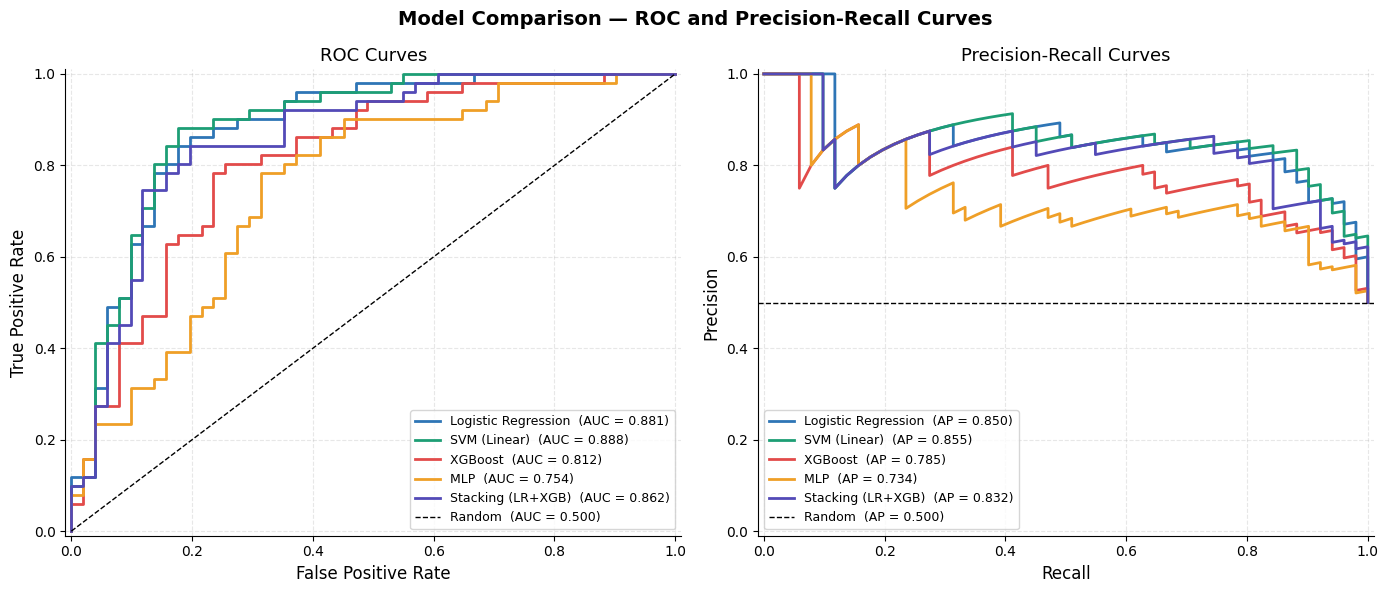

Saved: ../models/roc_and_pr_curves.png

  CURVE METRICS SUMMARY
  Model                       ROC-AUC    PR-AP
  --------------------------------------------
  Logistic Regression           0.881    0.850
  SVM (Linear)                  0.888    0.855
  XGBoost                       0.812    0.785
  MLP                           0.754    0.734
  Stacking (LR+XGB)             0.862    0.832


In [10]:
from evaluate import plot_roc_and_pr_curves

plot_roc_and_pr_curves(all_models, X_test_sel, y_test)

## Step 8 — 5-Fold Cross Validation

In [11]:
from evaluate import cross_validate_all

cross_validate_all(all_models, X_train_sel, y_train, cv=5)


  5-FOLD CROSS VALIDATION
  Model                     Mean F1    Std Dev
  --------------------------------------------
  Logistic Regression         76.5%       2.8%
  SVM (Linear)                74.9%       3.7%
  XGBoost                     71.8%       4.1%
  MLP                         70.6%       9.0%
  Stacking (LR+XGB)           73.5%       4.3%


## Step 9 — Final Model Comparison Summary

In [12]:
from evaluate import compare_models

compare_models(all_models, X_test_sel, y_test)


  FINAL MODEL COMPARISON
  Model                    Accuracy       F1   Recall  Precision
  ----------------------------------------------------------
  Logistic Regression         81.4%    80.8%    78.4%      83.3%
  SVM (Linear)                81.4%    80.4%    76.5%      84.8%
  Stacking (LR+XGB)           81.4%    80.0%    74.5%      86.4%
  XGBoost                     75.5%    75.2%    74.5%      76.0%
  MLP                         69.6%    69.3%    68.6%      70.0%

  Best model: Logistic Regression (81.4% accuracy)
